In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/Readme.txt
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_52_13.png
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_54_12.png
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_52_7.png
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_5_19.png
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_50_21.png
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_27_1.png
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_32_23.png
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_19_15.png
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_55_19.png
/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_12_1.png
/kaggle/input/datasets/shreelak

In [2]:
import h5py
import numpy as np
from numpy import zeros, ones, asarray, concatenate, array, asarray, pad
import os, sys
from PIL import Image, ImageOps
import cv2
import seaborn as sns
from h5py import File
from math import ceil, floor

In [3]:
def process_image(im, img_dim):
    w_new, h_new = img_dim
    im = im.convert('L')
    im = ImageOps.invert(im)
    w, h = im.size
    w_prime = min(w_new, w * h_new // h)
    h_prime = h * w_prime // w
    im = im.resize((w_prime, h_prime))
    img = asarray(im)
    top = floor((h_new - h_prime) / 2)
    bottom = ceil((h_new - h_prime) / 2)
    left = floor((w_new - w_prime) / 2)
    right = ceil((w_new - w_prime) / 2)
    img = pad(img, ((top, bottom), (left, right)))
    img = img.reshape(img.shape[0], img.shape[1], 1)
    return img

In [4]:
def process_batch(X, Y, L, img_dim, Dir, i, value):
    for infile in os.listdir(Dir):
        file = os.path.join(Dir, infile)
        try:
            with Image.open(file) as im:
                X[i] = process_image(im, img_dim)
                Y[i] = value
                L[i] = infile.split('_')[1]
                i = i + 1
        except Exception as ex:
            template = "An exception of type {0} occurred. Arguments:\n{1!r}"
            message = template.format(type(ex).__name__, ex.args)
            print(message)

In [5]:
img_dim = (224,224)
m = 2640

In [6]:
X = zeros((m,224,224, 1), dtype = np.uint8)
Y = zeros((m, 1), dtype = np.uint8)
L = zeros((m, 1), dtype = np.uint8)
BASE_DIR = os.getcwd()
i = 0
Dir = '/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org'
process_batch(X, Y, L, img_dim, Dir, i, 1)
i = 1320
Dir = '/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_forg'
process_batch(X, Y, L, img_dim, Dir, i, 0)
i = 2640
outfile = 'cedar_'+str(img_dim[0])+'x'+str(img_dim[1])+'.h5'
print(outfile)
file = os.path.join(BASE_DIR, outfile)
with File(outfile, 'w') as hdf:
    hdf.create_dataset('X', data = X)
    hdf.create_dataset('Y', data = Y)
    hdf.create_dataset('L', data = L)

An exception of type UnidentifiedImageError occurred. Arguments:
("cannot identify image file '/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/Thumbs.db'",)
An exception of type UnidentifiedImageError occurred. Arguments:
("cannot identify image file '/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_forg/Thumbs.db'",)
cedar_224x224.h5


In [7]:
def xor(x, y):
    z = x ^ y
    return z

In [8]:
img_dim = (224,224)
m = 2640
BASE_DIR = os.getcwd()
infile = 'cedar_'+str(img_dim[0])+'x'+str(img_dim[1])+'.h5'
file = os.path.join(BASE_DIR, infile)
with File(file, 'r') as hdf:
    X = array(hdf.get('X'))
    Y = array(hdf.get('Y'))
    L = array(hdf.get('L'))
writers = list()
for i in L.squeeze():
    if i not in writers:
        writers.append(i)
print(writers)

[np.uint8(52), np.uint8(54), np.uint8(5), np.uint8(50), np.uint8(27), np.uint8(32), np.uint8(19), np.uint8(55), np.uint8(12), np.uint8(44), np.uint8(21), np.uint8(22), np.uint8(26), np.uint8(53), np.uint8(11), np.uint8(7), np.uint8(36), np.uint8(31), np.uint8(47), np.uint8(1), np.uint8(30), np.uint8(24), np.uint8(3), np.uint8(8), np.uint8(18), np.uint8(15), np.uint8(49), np.uint8(33), np.uint8(28), np.uint8(9), np.uint8(25), np.uint8(38), np.uint8(14), np.uint8(23), np.uint8(51), np.uint8(41), np.uint8(34), np.uint8(4), np.uint8(43), np.uint8(2), np.uint8(45), np.uint8(37), np.uint8(46), np.uint8(39), np.uint8(17), np.uint8(42), np.uint8(40), np.uint8(10), np.uint8(35), np.uint8(29), np.uint8(13), np.uint8(20), np.uint8(16), np.uint8(6), np.uint8(48)]


In [9]:
n_writers = len(writers)
print(n_writers)
n_original = int(Y.sum() // n_writers)
print(n_original)
n_forged = int(len(Y.squeeze()) // n_writers - n_original)
print(n_forged)
m = int(n_writers * (n_original * n_forged + n_original * (n_original - 1) // 2))
print(m)

55
24
24
46860


In [10]:
S1 = np.zeros((m, X.shape[1], X.shape[2], X.shape[3]), dtype = np.uint8)
S2 = np.zeros((m, X.shape[1], X.shape[2], X.shape[3]), dtype = np.uint8)
y = np.zeros((m, 1), dtype = np.uint8)
w = np.zeros((m, 1), dtype = np.uint8)
l = 0
for writer in writers:
    ind = np.where(L.squeeze() == writer)
    if len(ind) != 1:
        print('Error')
    for i in ind[0]:
        for j in ind[0]:
            if i <= j:
                continue
            if Y.squeeze()[i] == 0 and Y.squeeze()[j] == 0:
                continue
            S1[l] = X[i]
            S2[l] = X[j]
            y[l] = xor(Y[i], Y[j])
            w[l][0] = writer
            l = l + 1
outfile = '/kaggle/working/'+'cedar_'+str(img_dim[0])+'x'+str(img_dim[1])+'_siamese.h5'
print(outfile)
# file =
with File(outfile, 'w') as hdf:
    hdf.create_dataset('S1', data = S1)
    hdf.create_dataset('S2', data = S2)
    hdf.create_dataset('Y',   data =   y)
    hdf.create_dataset('L',   data =   w)

/kaggle/working/cedar_224x224_siamese.h5


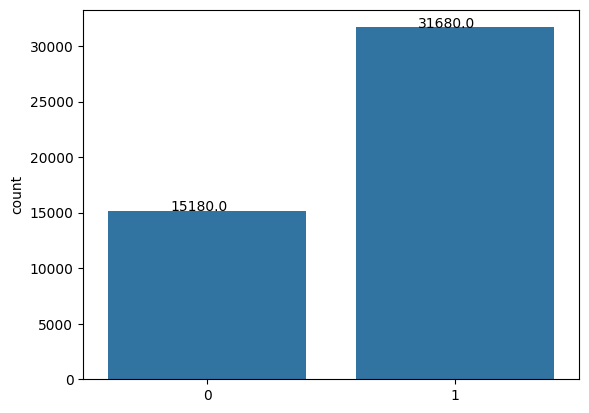

In [11]:
ax = sns.countplot(x = y.reshape(y.shape[0]))
for p in ax.patches:
   ax.annotate('{:}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))

In [12]:
from IPython.display import FileLink
FileLink(r'/kaggle/working/cedar_224x224.h5')

/kaggle/working/cedar_224x224.h5